# Este notebook analiza los **30 SBOM (Software Bill of Materials)** generados por **Syft** para los repositorios de TanStack.

Los SBOM utilizan **CycloneDX** como formato de intercambio y describen los componentes detectados en cada repositorio.

El análisis se concentra en:

- cantidad de componentes por repositorio;
- componentes y paquetes únicos;
- tipos de componentes y ecosistemas;
- dependencias compartidas entre repositorios;
- diversidad de versiones;
- componentes con versión `UNKNOWN`;
- cobertura de identificadores PURL y CPE;
- información de licencias;
- relaciones de dependencia incluidas en CycloneDX;
- concentración y reutilización de dependencias;
- resultados estructurados para el Visualizer.



## 1. Importaciones

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown


## 2. Localización de los archivos SBOM

In [2]:
import os

_env_sbom_dir = os.environ.get("ANALYZER_SBOM_DIR")

candidate_directories = []
if _env_sbom_dir:
    candidate_directories.append(Path(_env_sbom_dir))

candidate_directories += [
    Path("../../results-sboms"),
    Path("../../resultados-sbom"),
    Path("../results-sboms"),
    Path("../resultados-sbom"),
    Path("results-sboms"),
    Path("resultados-sbom"),
    Path("."),
]

SBOM_DIR = next(
    (
        directory
        for directory in candidate_directories
        if directory.exists() and list(directory.glob("*.cdx.json"))
    ),
    None
)

if SBOM_DIR is None:
    raise FileNotFoundError(
        "No se encontró una carpeta con archivos *.cdx.json. "
        "Define ANALYZER_SBOM_DIR o ajusta candidate_directories."
    )

sbom_files = sorted(SBOM_DIR.glob("*.cdx.json"))

print("Carpeta utilizada:", SBOM_DIR.resolve())
print("Cantidad de SBOM encontrados:", len(sbom_files))

for path in sbom_files:
    print("-", path.name)

Carpeta utilizada: /workspaces/dev-container-test/deliverables/miner/results-sboms
Cantidad de SBOM encontrados: 30
- ai.cdx.json
- alt-cli.cdx.json
- bling.cdx.json
- charts.cdx.json
- cli.cdx.json
- config.cdx.json
- container.cdx.json
- db.cdx.json
- devtools.cdx.json
- form.cdx.json
- highlight.cdx.json
- hotkeys.cdx.json
- intent.cdx.json
- markdown.cdx.json
- pacer.cdx.json
- persist.cdx.json
- preact.cdx.json
- query.cdx.json
- ranger.cdx.json
- react-charts.cdx.json
- redact.cdx.json
- router.cdx.json
- select.cdx.json
- store.cdx.json
- table.cdx.json
- tanstack.com.cdx.json
- template.cdx.json
- time.cdx.json
- virtual.cdx.json
- workflow.cdx.json


Para esta ejecución de TanStack se esperan **30 archivos SBOM**. El notebook no se detiene si la cantidad cambia, pero muestra una advertencia para mantener la trazabilidad de la ejecución.

## 3. Validación de formato y metadatos

In [3]:
metadata_rows = []

for path in sbom_files:
    with open(path, "r", encoding="utf-8") as f:
        sbom = json.load(f)

    tools = (
        sbom.get("metadata", {})
        .get("tools", {})
        .get("components", [])
        or []
    )

    syft_tool = next(
        (
            tool for tool in tools
            if str(tool.get("name", "")).lower() == "syft"
        ),
        {}
    )

    metadata_rows.append({
        "repository": path.name.replace(".cdx.json", ""),
        "bom_format": sbom.get("bomFormat"),
        "spec_version": sbom.get("specVersion"),
        "serial_number": sbom.get("serialNumber"),
        "timestamp": sbom.get("metadata", {}).get("timestamp"),
        "syft_version": syft_tool.get("version"),
        "raw_components": len(sbom.get("components", []) or []),
        "dependency_nodes": len(sbom.get("dependencies", []) or [])
    })

df_metadata = pd.DataFrame(metadata_rows).sort_values("repository")

df_metadata


,repository,bom_format,spec_version,serial_number,timestamp,syft_version,raw_components,dependency_nodes
0,ai,CycloneDX,1.7,urn:uuid:614152db-a843-43e6-9ab4-fa151567daf5,2026-10-09T04:44:40Z,1.54.1,3165,1563
1,alt-cli,CycloneDX,1.7,urn:uuid:e805bf94-964e-4659-aacd-68c7750d6f26,2026-10-09T04:51:15Z,1.54.1,676,263
2,bling,CycloneDX,1.7,urn:uuid:13541fcf-ad1f-4648-8f37-b53e618facc3,2026-10-09T04:51:45Z,1.54.1,534,255
3,charts,CycloneDX,1.7,urn:uuid:c90b44c4-8ac4-4658-9905-b84d89fc4409,2026-10-09T04:52:15Z,1.54.1,1196,564
4,cli,CycloneDX,1.7,urn:uuid:1fced9db-9b63-47c7-8701-dfa327e45c59,2026-10-09T04:55:01Z,1.54.1,1767,813
5,config,CycloneDX,1.7,urn:uuid:b9e48e9a-3c69-4ef1-a07a-9af7b3476f85,2026-10-09T04:55:44Z,1.54.1,654,282
6,container,CycloneDX,1.7,urn:uuid:547552ef-fec0-486f-90cb-46ffdfc6f389,2026-10-09T04:56:11Z,1.54.1,2195,940
7,db,CycloneDX,1.7,urn:uuid:5303a4dd-8b63-4799-befe-2b8be6c7b930,2026-10-09T04:58:56Z,1.54.1,4373,1949
8,devtools,CycloneDX,1.7,urn:uuid:dc4bdb97-dfa2-40ed-a0ce-cc524123a2d3,2026-10-09T05:05:10Z,1.54.1,3172,1462
9,form,CycloneDX,1.7,urn:uuid:ec82fd4d-44a3-49bf-98a1-43ad6ff9f9de,2026-10-09T05:05:56Z,1.54.1,2712,1437


In [4]:
print("SBOM procesados:", len(df_metadata))
print("Formatos:", df_metadata["bom_format"].dropna().unique())
print("Versiones CycloneDX:", df_metadata["spec_version"].dropna().unique())
print("Versiones Syft:", df_metadata["syft_version"].dropna().unique())

invalid_format = df_metadata[
    df_metadata["bom_format"].fillna("") != "CycloneDX"
]

if invalid_format.empty:
    print("\nTodos los archivos declaran formato CycloneDX.")
else:
    print("\nADVERTENCIA: existen archivos que no declaran CycloneDX:")
    display(invalid_format)

if len(df_metadata) == 30:
    print("Se encontraron los 30 SBOM esperados.")
else:
    print(
        f"ADVERTENCIA: se esperaban 30 SBOM y se encontraron {len(df_metadata)}."
    )


SBOM procesados: 30
Formatos: <StringArray>
['CycloneDX']
Length: 1, dtype: str
Versiones CycloneDX: <StringArray>
['1.7']
Length: 1, dtype: str
Versiones Syft: <StringArray>
['1.54.1']
Length: 1, dtype: str

Todos los archivos declaran formato CycloneDX.
Se encontraron los 30 SBOM esperados.


Los archivos de esta ejecución deben ser comparables entre sí. También es útil verificar que fueron generados con la misma versión de Syft y la misma versión de CycloneDX.

## 4. Extracción de componentes y relaciones

In [5]:
component_rows = []
dependency_rows = []

def extract_licenses(component):
    values = []

    for item in component.get("licenses", []) or []:
        if not isinstance(item, dict):
            continue

        license_obj = item.get("license")

        if isinstance(license_obj, dict):
            value = license_obj.get("id") or license_obj.get("name")
            if value:
                values.append(value)

        if item.get("expression"):
            values.append(item["expression"])

    return " | ".join(sorted(set(values)))


def extract_ecosystem(purl):
    if not isinstance(purl, str) or not purl.startswith("pkg:"):
        return None

    return purl[4:].split("/", 1)[0]


for path in sbom_files:
    repository = path.name.replace(".cdx.json", "")

    with open(path, "r", encoding="utf-8") as f:
        sbom = json.load(f)

    for component in sbom.get("components", []) or []:
        properties_list = component.get("properties", []) or []

        properties = {
            item.get("name"): item.get("value")
            for item in properties_list
            if isinstance(item, dict) and item.get("name")
        }

        locations = [
            item.get("value")
            for item in properties_list
            if (
                isinstance(item, dict)
                and str(item.get("name", "")).startswith("syft:location:")
                and str(item.get("name", "")).endswith(":path")
                and item.get("value")
            )
        ]

        purl = component.get("purl")

        component_rows.append({
            "repository": repository,
            "component_type": component.get("type"),
            "name": component.get("name"),
            "version": component.get("version"),
            "purl": purl,
            "ecosystem": extract_ecosystem(purl),
            "cpe": component.get("cpe"),
            "licenses": extract_licenses(component),
            "found_by": properties.get("syft:package:foundBy"),
            "language": properties.get("syft:package:language"),
            "package_type": properties.get("syft:package:type"),
            "metadata_type": properties.get("syft:package:metadataType"),
            "location": locations[0] if locations else None,
            "bom_ref": component.get("bom-ref")
        })

    for dependency in sbom.get("dependencies", []) or []:
        source = dependency.get("ref")

        for target in dependency.get("dependsOn", []) or []:
            dependency_rows.append({
                "repository": repository,
                "source_ref": source,
                "target_ref": target
            })

component_columns = [
    "repository", "component_type", "name", "version", "purl",
    "ecosystem", "cpe", "licenses", "found_by", "language",
    "package_type", "metadata_type", "location", "bom_ref"
]

dependency_columns = [
    "repository", "source_ref", "target_ref"
]

df_components_raw = pd.DataFrame(
    component_rows,
    columns=component_columns
)

df_dependency_edges = pd.DataFrame(
    dependency_rows,
    columns=dependency_columns
)

print("Apariciones de componentes:", len(df_components_raw))
print("Relaciones de dependencia:", len(df_dependency_edges))

df_components_raw.head()


Apariciones de componentes: 46229
Relaciones de dependencia: 122364


,repository,component_type,name,version,purl,ecosystem,cpe,licenses,found_by,language,package_type,metadata_type,location,bom_ref
0,ai,library,@acemir/cssom,0.9.31,pkg:npm/%40acemir/cssom@0.9.31,npm,cpe:2.3:a:\@acemir\/cssom:\@acemir\/cssom:0.9....,,javascript-lock-cataloger,javascript,npm,javascript-pnpm-lock-entry,/pnpm-lock.yaml,pkg:npm/%40acemir/cssom@0.9.31?package-id=34ae...
1,ai,library,@ag-ui/core,1.0.0,pkg:npm/%40ag-ui/core@1.0.0,npm,cpe:2.3:a:\@ag-ui\/core:\@ag-ui\/core:1.0.0:*:...,,javascript-lock-cataloger,javascript,npm,javascript-pnpm-lock-entry,/pnpm-lock.yaml,pkg:npm/%40ag-ui/core@1.0.0?package-id=589ddf8...
2,ai,library,@agentclientprotocol/sdk,0.25.1,pkg:npm/%40agentclientprotocol/sdk@0.25.1,npm,cpe:2.3:a:\@agentclientprotocol\/sdk:\@agentcl...,,javascript-lock-cataloger,javascript,npm,javascript-pnpm-lock-entry,/pnpm-lock.yaml,pkg:npm/%40agentclientprotocol/sdk@0.25.1?pack...
3,ai,library,@ampproject/remapping,2.3.0,pkg:npm/%40ampproject/remapping@2.3.0,npm,cpe:2.3:a:\@ampproject\/remapping:\@ampproject...,,javascript-lock-cataloger,javascript,npm,javascript-pnpm-lock-entry,/pnpm-lock.yaml,pkg:npm/%40ampproject/remapping@2.3.0?package-...
4,ai,library,@analogjs/vite-plugin-angular,2.6.3,pkg:npm/%40analogjs/vite-plugin-angular@2.6.3,npm,cpe:2.3:a:\@analogjs\/vite-plugin-angular:\@an...,,javascript-lock-cataloger,javascript,npm,javascript-pnpm-lock-entry,/pnpm-lock.yaml,pkg:npm/%40analogjs/vite-plugin-angular@2.6.3?...


Syft puede registrar un mismo paquete más de una vez si aparece en diferentes archivos de bloqueo o ubicaciones. Por eso se conservarán dos vistas:

- `df_components_raw`: todas las apariciones detectadas;
- `df_components`: componentes únicos dentro de cada repositorio.


## 5. Deduplicación de componentes

In [6]:
df_components_raw["component_identity"] = (
    df_components_raw["purl"]
    .fillna(
        df_components_raw["name"].fillna("")
        + "@"
        + df_components_raw["version"].fillna("UNKNOWN")
        + "#"
        + df_components_raw["component_type"].fillna("")
    )
)

df_components = (
    df_components_raw
    .drop_duplicates(
        subset=["repository", "component_identity"]
    )
    .copy()
)

print("Apariciones originales:", len(df_components_raw))
print("Componentes únicos por repositorio:", len(df_components))
print(
    "Apariciones duplicadas eliminadas:",
    len(df_components_raw) - len(df_components)
)


Apariciones originales: 46229
Componentes únicos por repositorio: 42429
Apariciones duplicadas eliminadas: 3800


## 6. Componentes por repositorio

In [7]:
repo_summary = df_components.groupby("repository").agg(
    unique_components=("component_identity", "nunique"),
    unique_component_names=("name", "nunique"),
    npm_components=("package_type", lambda s: (s == "npm").sum()),
    github_action_components=(
        "package_type",
        lambda s: s.isin(
            ["github-action", "github-action-workflow"]
        ).sum()
    ),
    unknown_versions=(
        "version",
        lambda s: s.fillna("UNKNOWN").eq("UNKNOWN").sum()
    ),
    with_purl=("purl", lambda s: s.notna().sum()),
    with_cpe=("cpe", lambda s: s.notna().sum()),
    with_license=(
        "licenses",
        lambda s: s.fillna("").ne("").sum()
    )
)

raw_counts = (
    df_components_raw.groupby("repository")
    .size()
    .rename("raw_component_occurrences")
)

repo_summary = repo_summary.join(raw_counts)

repo_summary["purl_percentage"] = (
    repo_summary["with_purl"]
    / repo_summary["unique_components"]
    * 100
).replace([np.inf, -np.inf], np.nan).fillna(0).round(2)

repo_summary["cpe_percentage"] = (
    repo_summary["with_cpe"]
    / repo_summary["unique_components"]
    * 100
).replace([np.inf, -np.inf], np.nan).fillna(0).round(2)

repo_summary["license_percentage"] = (
    repo_summary["with_license"]
    / repo_summary["unique_components"]
    * 100
).replace([np.inf, -np.inf], np.nan).fillna(0).round(2)

# Agrega repositorios con SBOM vacío para que no desaparezcan del resumen.
all_repositories = pd.Index(
    df_metadata["repository"],
    name="repository"
)

repo_summary = (
    repo_summary
    .reindex(all_repositories)
    .fillna(0)
)

integer_columns = [
    "unique_components",
    "unique_component_names",
    "npm_components",
    "github_action_components",
    "unknown_versions",
    "with_purl",
    "with_cpe",
    "with_license",
    "raw_component_occurrences"
]

repo_summary[integer_columns] = (
    repo_summary[integer_columns].astype(int)
)

repo_summary = repo_summary.sort_values(
    "unique_components",
    ascending=False
)

repo_summary


,unique_components,unique_component_names,npm_components,github_action_components,unknown_versions,with_purl,with_cpe,with_license,raw_component_occurrences,purl_percentage,cpe_percentage,license_percentage
repository,,,,,,,,,,,,
db,3168,2049,3140,12,16,3153,3153,1,4373,99.53,99.53,0.03
ai,3146,2533,2977,10,13,3132,3133,0,3165,99.55,99.59,0.00
query,3059,2424,3046,8,5,3054,3054,0,3064,99.84,99.84,0.00
router,2916,2099,2896,11,9,2907,2907,0,2926,99.69,99.69,0.00
table,2806,2113,2789,11,6,2800,2800,0,2811,99.79,99.79,0.00
devtools,2747,1982,2722,13,12,2735,2735,0,3172,99.56,99.56,0.00
form,2707,2173,2693,9,5,2702,2702,0,2712,99.82,99.82,0.00
hotkeys,2165,1597,2152,8,5,2160,2160,0,2170,99.77,99.77,0.00
pacer,1823,1444,1809,9,5,1818,1818,0,1828,99.73,99.73,0.00


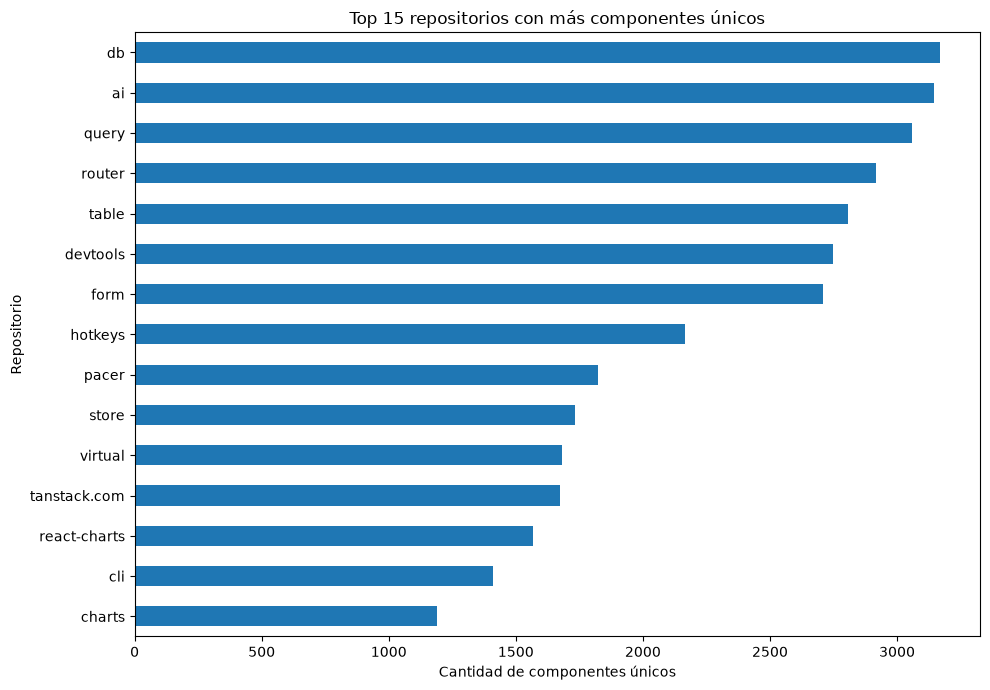

In [8]:
repo_summary["unique_components"].head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Top 15 repositorios con más componentes únicos")
plt.xlabel("Cantidad de componentes únicos")
plt.ylabel("Repositorio")
plt.tight_layout()
plt.show()


## 7. SBOM vacíos

In [9]:
empty_sboms = df_metadata[
    df_metadata["raw_components"] == 0
][["repository", "raw_components"]]

empty_sboms


,repository,raw_components
27,time,0


In [10]:
if empty_sboms.empty:
    display(Markdown("No se identificaron SBOM vacíos."))
else:
    names = ", ".join(
        f"`{repo}`"
        for repo in empty_sboms["repository"]
    )

    display(Markdown(
        f"Se identificaron **{len(empty_sboms)} SBOM vacíos**: {names}. "
        "Un SBOM vacío indica que Syft no registró componentes para ese repositorio; "
        "no significa automáticamente que el repositorio sea seguro ni que carezca de código."
    ))


Se identificaron **1 SBOM vacíos**: `time`. Un SBOM vacío indica que Syft no registró componentes para ese repositorio; no significa automáticamente que el repositorio sea seguro ni que carezca de código.

## 8. Tipos de componentes

In [11]:
component_type_counts = (
    df_components["component_type"]
    .fillna("sin_clasificar")
    .value_counts()
)

component_type_counts


component_type
library    42226
file         203
Name: count, dtype: int64

In [12]:
package_type_counts = (
    df_components["package_type"]
    .fillna("sin_clasificar")
    .value_counts()
)

package_type_counts


package_type
npm                       41835
github-action               234
sin_clasificar              203
rust-crate                  146
github-action-workflow        7
go-module                     3
java-archive                  1
Name: count, dtype: int64

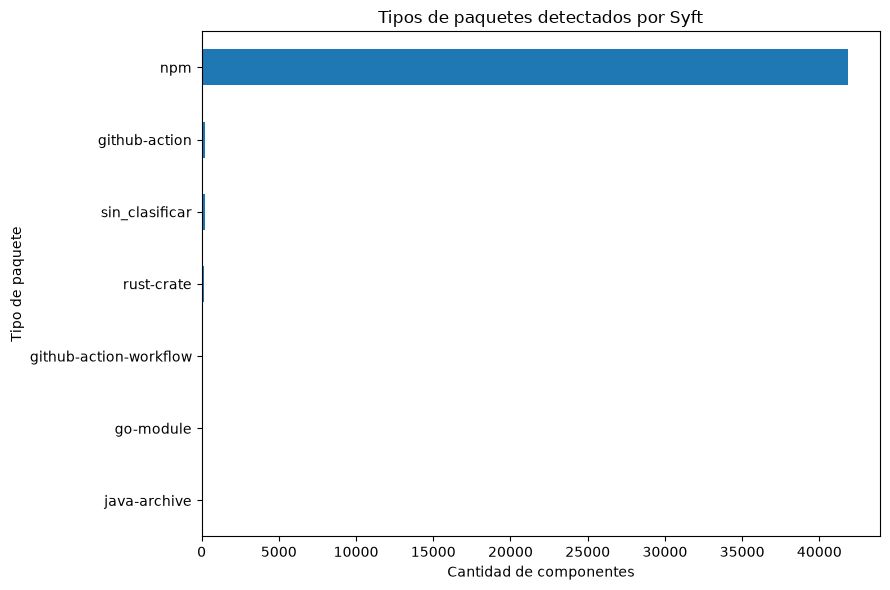

In [13]:
package_type_counts.head(10).sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Tipos de paquetes detectados por Syft")
plt.xlabel("Cantidad de componentes")
plt.ylabel("Tipo de paquete")
plt.tight_layout()
plt.show()


Los SBOM no contienen únicamente paquetes npm. Syft también puede detectar elementos como GitHub Actions y workflows. Separarlos evita interpretar erróneamente todos los componentes como dependencias JavaScript.

## 9. Ecosistemas identificados mediante PURL

In [14]:
ecosystem_counts = (
    df_components["ecosystem"]
    .fillna("sin_purl")
    .value_counts()
)

ecosystem_counts


ecosystem
npm         41835
github        231
sin_purl      214
cargo         145
golang          3
maven           1
Name: count, dtype: int64

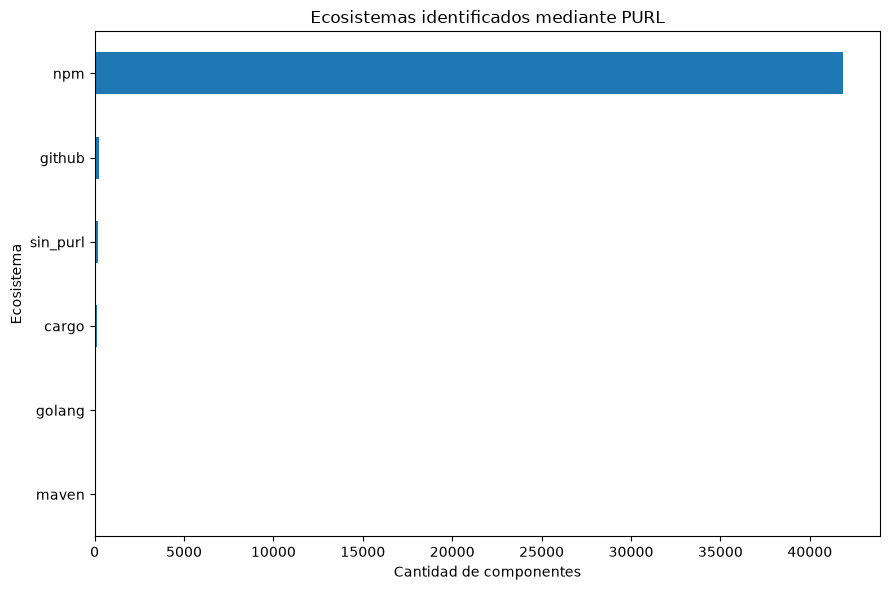

In [15]:
ecosystem_counts.head(10).sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Ecosistemas identificados mediante PURL")
plt.xlabel("Cantidad de componentes")
plt.ylabel("Ecosistema")
plt.tight_layout()
plt.show()


## 10. Paquetes npm compartidos entre repositorios

In [16]:
df_npm = df_components[
    df_components["package_type"] == "npm"
].copy()

shared_packages = (
    df_npm.groupby("name")
    .agg(
        repositories=("repository", "nunique"),
        distinct_versions=("version", "nunique"),
        occurrences=("repository", "size")
    )
    .sort_values(
        ["repositories", "occurrences"],
        ascending=False
    )
)

shared_packages.head(25)


,repositories,distinct_versions,occurrences
name,,,
picomatch,28,8,75
postcss,28,23,57
argparse,28,2,47
magic-string,28,13,47
@jridgewell/sourcemap-codec,28,6,39
semver,27,14,98
typescript,27,14,73
debug,27,6,61
@types/node,27,34,60


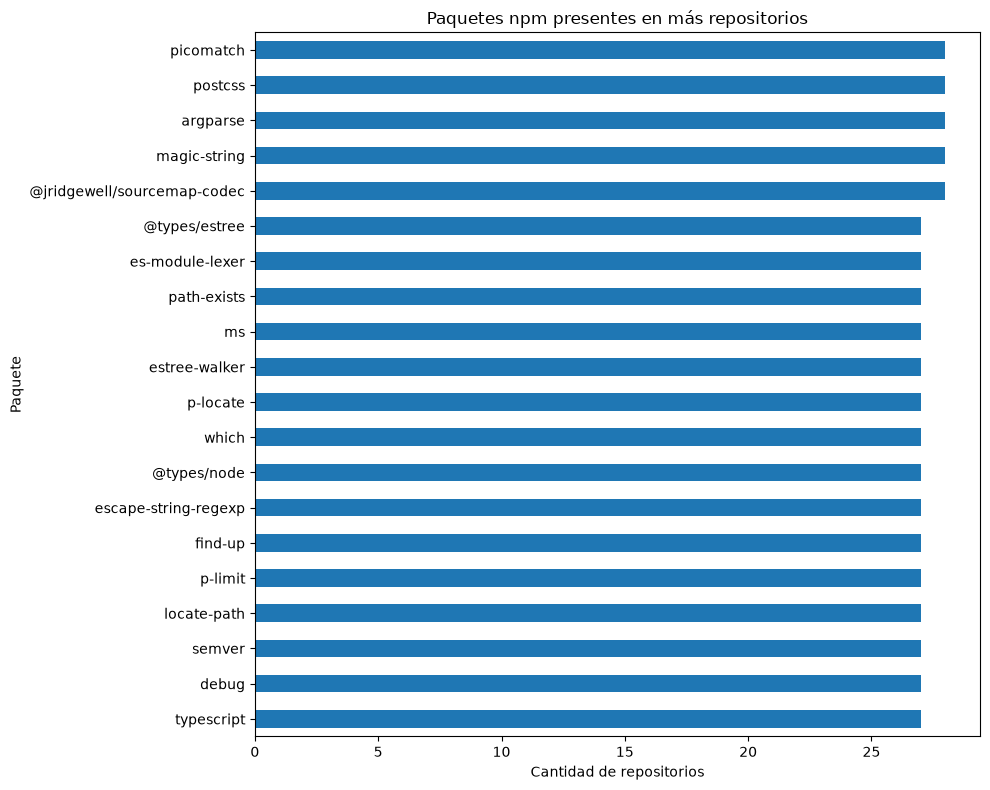

In [17]:
shared_packages["repositories"].head(20).sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("Paquetes npm presentes en más repositorios")
plt.xlabel("Cantidad de repositorios")
plt.ylabel("Paquete")
plt.tight_layout()
plt.show()


La cantidad de repositorios en que aparece un paquete permite medir su **reutilización organizacional**. Una dependencia muy compartida tiene mayor alcance potencial dentro de la organización si posteriormente Grype identifica una vulnerabilidad asociada a ella.

## 11. Cobertura organizacional de paquetes

In [18]:
repository_count = df_metadata["repository"].nunique()

package_coverage = shared_packages.copy()

package_coverage["repository_percentage"] = (
    package_coverage["repositories"]
    / repository_count
    * 100
).round(2)

package_coverage.head(25)


,repositories,distinct_versions,occurrences,repository_percentage
name,,,,
picomatch,28,8,75,93.33
postcss,28,23,57,93.33
argparse,28,2,47,93.33
magic-string,28,13,47,93.33
@jridgewell/sourcemap-codec,28,6,39,93.33
semver,27,14,98,90.00
typescript,27,14,73,90.00
debug,27,6,61,90.00
@types/node,27,34,60,90.00


In [19]:
widely_shared = package_coverage[
    package_coverage["repository_percentage"] >= 50
]

print(
    "Paquetes npm presentes en al menos el 50% de los repositorios:",
    len(widely_shared)
)

widely_shared.head(30)


Paquetes npm presentes en al menos el 50% de los repositorios: 714


,repositories,distinct_versions,occurrences,repository_percentage
name,,,,
picomatch,28,8,75,93.33
postcss,28,23,57,93.33
argparse,28,2,47,93.33
magic-string,28,13,47,93.33
@jridgewell/sourcemap-codec,28,6,39,93.33
semver,27,14,98,90.00
typescript,27,14,73,90.00
debug,27,6,61,90.00
@types/node,27,34,60,90.00


## 12. Diversidad de versiones

In [20]:
version_diversity = (
    df_npm[
        df_npm["version"].notna()
        & df_npm["version"].ne("UNKNOWN")
    ]
    .groupby("name")
    .agg(
        distinct_versions=("version", "nunique"),
        repositories=("repository", "nunique")
    )
    .query("distinct_versions > 1")
    .sort_values(
        ["distinct_versions", "repositories"],
        ascending=False
    )
)

version_diversity.head(25)


,distinct_versions,repositories
name,,
@types/node,34,27
vite,26,26
@oxc-project/types,24,22
@typescript-eslint/types,24,19
postcss,23,28
@esbuild/android-arm,23,26
@esbuild/linux-loong64,23,26
esbuild,23,26
undici,23,21


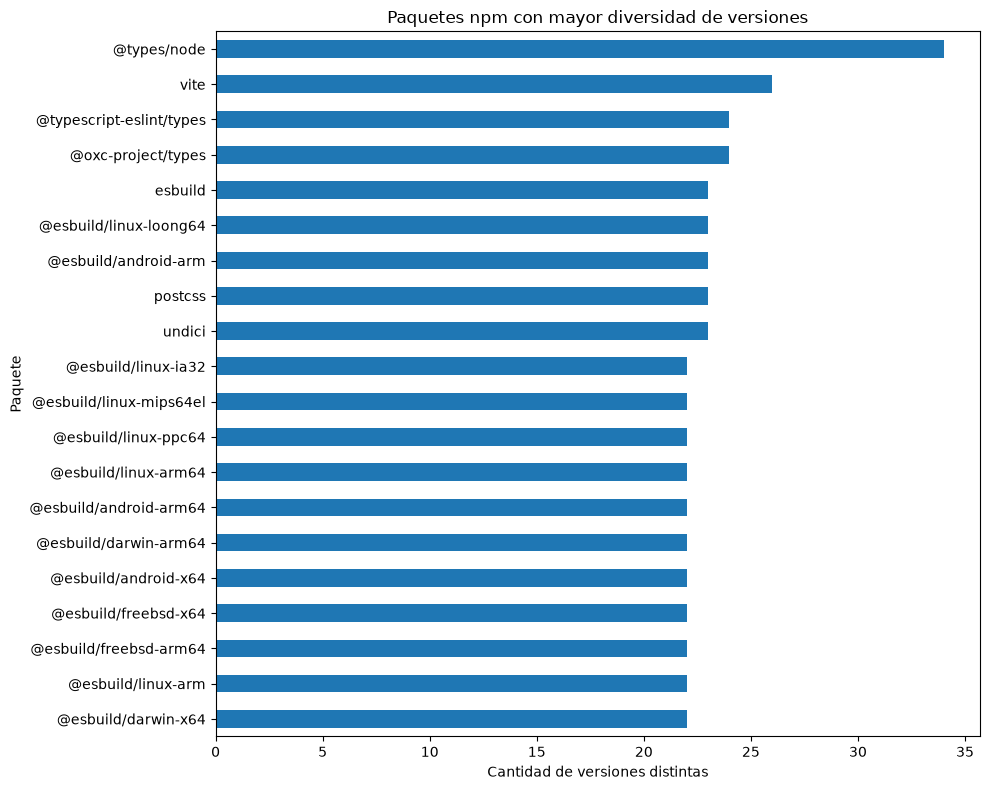

In [21]:
if version_diversity.empty:
    display(Markdown("No se identificaron paquetes npm con más de una versión."))
else:
    version_diversity["distinct_versions"].head(20).sort_values().plot(
        kind="barh",
        figsize=(10, 8)
    )

    plt.title("Paquetes npm con mayor diversidad de versiones")
    plt.xlabel("Cantidad de versiones distintas")
    plt.ylabel("Paquete")
    plt.tight_layout()
    plt.show()


La diversidad de versiones no equivale a una vulnerabilidad. Sin embargo, revela heterogeneidad en la gestión de dependencias y puede ayudar a explicar por qué una misma vulnerabilidad Grype aparece de forma diferente entre repositorios.

## 13. Detalle de versiones por paquete

In [22]:
package_versions = (
    df_npm[
        df_npm["version"].notna()
    ]
    .groupby("name")["version"]
    .apply(lambda s: sorted(set(s)))
    .rename("versions")
    .to_frame()
)

package_versions["version_count"] = (
    package_versions["versions"].apply(len)
)

package_versions.sort_values(
    "version_count",
    ascending=False
).head(20)


,versions,version_count
name,,
@types/node,"[10.12.18, 12.20.55, 14.0.20, 14.0.27, 18.19.1...",34
vite,"[3.2.5, 5.4.21, 6.1.1, 6.3.3, 6.3.5, 6.4.1, 6....",26
@typescript-eslint/types,"[8.23.0, 8.25.0, 8.31.0, 8.38.0, 8.39.0, 8.44....",24
@oxc-project/types,"[0.101.0, 0.107.0, 0.108.0, 0.113.0, 0.115.0, ...",24
undici,"[5.20.0, 6.21.2, 6.21.3, 6.23.0, 6.26.0, 6.27....",23
@esbuild/linux-loong64,"[0.15.18, 0.16.17, 0.17.6, 0.18.20, 0.19.12, 0...",23
esbuild,"[0.15.18, 0.16.17, 0.17.6, 0.18.20, 0.19.12, 0...",23
postcss,"[6.0.23, 7.0.21, 7.0.27, 7.0.29, 7.0.32, 8.4.2...",23
@esbuild/android-arm,"[0.15.18, 0.16.17, 0.17.6, 0.18.20, 0.19.12, 0...",23


## 14. Componentes con versión desconocida

In [23]:
unknown_version_components = df_components[
    df_components["version"]
    .fillna("UNKNOWN")
    .eq("UNKNOWN")
].copy()

print(
    "Componentes con versión UNKNOWN:",
    len(unknown_version_components)
)

unknown_version_components[
    [
        "repository",
        "name",
        "component_type",
        "package_type",
        "location"
    ]
].head(30)


Componentes con versión UNKNOWN: 227


,repository,name,component_type,package_type,location
3152,ai,/workspaces/dev-container-test/.miner-work/ai/...,file,NaN,NaN
3153,ai,/workspaces/dev-container-test/.miner-work/ai/...,file,NaN,NaN
3154,ai,/workspaces/dev-container-test/.miner-work/ai/...,file,NaN,NaN
3155,ai,/workspaces/dev-container-test/.miner-work/ai/...,file,NaN,NaN
3156,ai,/workspaces/dev-container-test/.miner-work/ai/...,file,NaN,NaN
3157,ai,/workspaces/dev-container-test/.miner-work/ai/...,file,NaN,NaN
3158,ai,/workspaces/dev-container-test/.miner-work/ai/...,file,NaN,NaN
3159,ai,/workspaces/dev-container-test/.miner-work/ai/...,file,NaN,NaN
3160,ai,/workspaces/dev-container-test/.miner-work/ai/...,file,NaN,NaN
3161,ai,/workspaces/dev-container-test/.miner-work/ai/...,file,NaN,NaN


In [24]:
unknown_by_type = (
    unknown_version_components["package_type"]
    .fillna("sin_clasificar")
    .value_counts()
)

unknown_by_type


package_type
sin_clasificar            203
npm                        13
github-action-workflow      6
github-action               4
java-archive                1
Name: count, dtype: int64

In [25]:
unknown_by_repo = (
    unknown_version_components["repository"]
    .value_counts()
)

unknown_by_repo.head(15)


repository
container       38
db              16
preact          16
ai              13
devtools        12
cli             10
intent           9
router           9
config           8
charts           7
table            6
tanstack.com     6
form             5
hotkeys          5
markdown         5
Name: count, dtype: int64

Los componentes con versión `UNKNOWN` suelen corresponder a acciones o workflows locales y otros componentes para los que no existe una versión convencional detectable. No deben tratarse automáticamente como paquetes npm con información faltante.

## 15. Cobertura de PURL y CPE

In [26]:
purl_count = int(df_components["purl"].notna().sum())
cpe_count = int(df_components["cpe"].notna().sum())
component_count = len(df_components)

purl_percentage = (
    purl_count / component_count * 100
    if component_count else 0
)

cpe_percentage = (
    cpe_count / component_count * 100
    if component_count else 0
)

identifier_coverage = pd.DataFrame({
    "identificador": ["PURL", "CPE"],
    "con_identificador": [purl_count, cpe_count],
    "porcentaje": [
        round(purl_percentage, 2),
        round(cpe_percentage, 2)
    ]
})

identifier_coverage


,identificador,con_identificador,porcentaje
0,PURL,42215,99.50
1,CPE,42225,99.52


PURL es especialmente útil para identificar un paquete por ecosistema, nombre y versión, mientras que CPE proporciona otra forma estandarizada de identificación. La disponibilidad de estos identificadores facilita el cruce con herramientas como Grype.

## 16. Información de licencias

In [27]:
license_mask = (
    df_components["licenses"]
    .fillna("")
    .ne("")
)

license_count = int(license_mask.sum())

license_percentage = (
    license_count / len(df_components) * 100
    if len(df_components) else 0
)

print(
    f"Componentes con información de licencia: "
    f"{license_count} ({license_percentage:.2f}%)"
)


Componentes con información de licencia: 929 (2.19%)


In [28]:
license_counts = (
    df_components.loc[license_mask, "licenses"]
    .value_counts()
)

license_counts.head(20)


licenses
MIT                                         741
Apache-2.0                                   83
ISC                                          29
BSD-2-Clause                                 17
MPL-2.0                                      14
BSD-3-Clause                                 12
LGPL-3.0-or-later                            10
BlueOak-1.0.0                                 5
Apache-2.0 AND LGPL-3.0-or-later              3
CC-BY-4.0                                     3
Unlicense                                     2
CC0-1.0                                       2
Apache-2.0 AND LGPL-3.0-or-later AND MIT      1
Apache-2.0 AND MIT                            1
Unlicense OR Apache-2.0                       1
Python-2.0                                    1
Artistic-2.0                                  1
MIT AND Zlib                                  1
MIT AND BSD-3-Clause                          1
0BSD                                          1
Name: count, dtype: int64

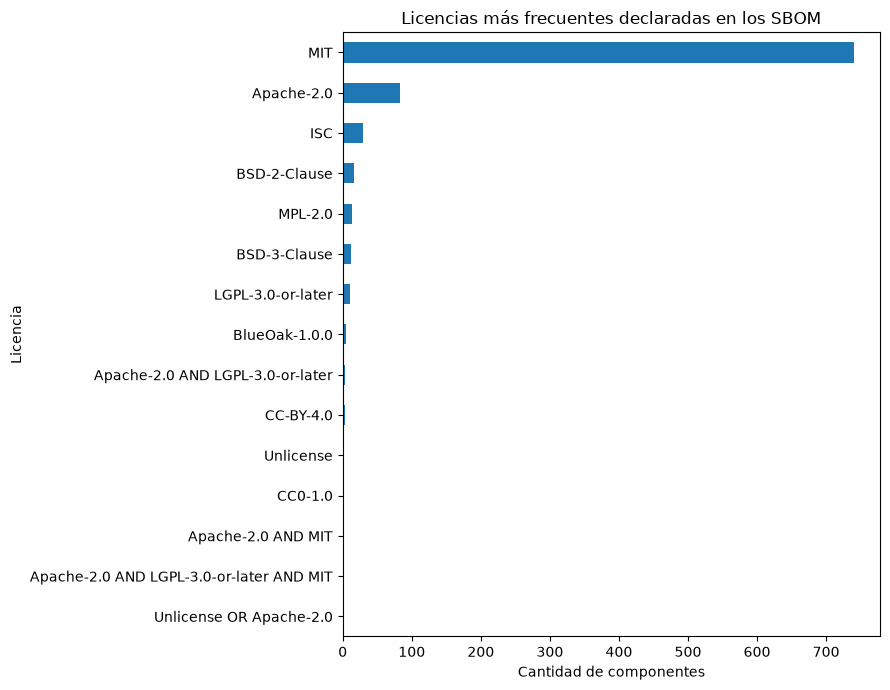

In [29]:
license_counts.head(15).sort_values().plot(
    kind="barh",
    figsize=(9, 7)
)

plt.title("Licencias más frecuentes declaradas en los SBOM")
plt.xlabel("Cantidad de componentes")
plt.ylabel("Licencia")
plt.tight_layout()
plt.show()


La ausencia de licencia en el SBOM no significa necesariamente que un componente carezca de licencia; indica que Syft no incorporó esa información para esa detección.

## 17. Relaciones de dependencia CycloneDX

In [30]:
if df_dependency_edges.empty:
    dependency_summary = pd.DataFrame(
        columns=[
            "dependency_edges",
            "dependency_sources",
            "dependency_targets"
        ]
    )
else:
    dependency_summary = (
        df_dependency_edges.groupby("repository")
        .agg(
            dependency_edges=("target_ref", "size"),
            dependency_sources=("source_ref", "nunique"),
            dependency_targets=("target_ref", "nunique")
        )
        .sort_values(
            "dependency_edges",
            ascending=False
        )
    )

dependency_summary.head(15)


,dependency_edges,dependency_sources,dependency_targets
repository,,,
table,10989,1573,2175
query,10372,1575,2501
db,10112,1949,3348
ai,9959,1563,2467
router,9562,1348,2220
form,9404,1437,2212
hotkeys,7566,1096,1671
devtools,7467,1462,2547
pacer,5833,901,1402


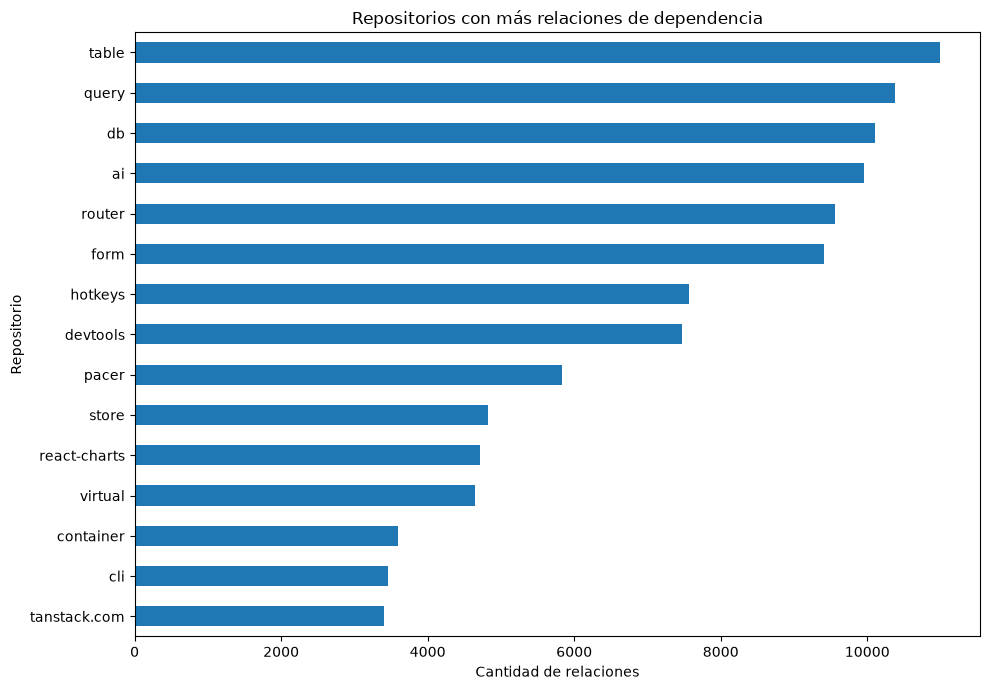

In [31]:
if not dependency_summary.empty:
    dependency_summary["dependency_edges"].head(15).sort_values().plot(
        kind="barh",
        figsize=(10, 7)
    )

    plt.title("Repositorios con más relaciones de dependencia")
    plt.xlabel("Cantidad de relaciones")
    plt.ylabel("Repositorio")
    plt.tight_layout()
    plt.show()


Las relaciones CycloneDX permiten aproximarse a la complejidad del grafo de dependencias. Un mayor número de relaciones no implica automáticamente mayor riesgo de seguridad.

## 18. Componentes exclusivos y compartidos

In [32]:
component_repository_frequency = (
    df_components.groupby(
        ["package_type", "name"],
        dropna=False
    )["repository"]
    .nunique()
    .rename("repositories")
    .reset_index()
)

exclusive_components = component_repository_frequency[
    component_repository_frequency["repositories"] == 1
]

shared_components = component_repository_frequency[
    component_repository_frequency["repositories"] > 1
]

print(
    "Nombres de componentes exclusivos de un repositorio:",
    len(exclusive_components)
)

print(
    "Nombres de componentes compartidos entre 2 o más repositorios:",
    len(shared_components)
)


Nombres de componentes exclusivos de un repositorio: 2483
Nombres de componentes compartidos entre 2 o más repositorios: 3841


## 19. Concentración de componentes

In [33]:
component_concentration = (
    repo_summary[["unique_components"]]
    .sort_values(
        "unique_components",
        ascending=False
    )
    .copy()
)

total_repo_components = (
    component_concentration["unique_components"].sum()
)

component_concentration["percentage"] = (
    component_concentration["unique_components"]
    / total_repo_components
    * 100
).round(2)

component_concentration["cumulative_percentage"] = (
    component_concentration["percentage"]
    .cumsum()
    .round(2)
)

component_concentration.head(15)


,unique_components,percentage,cumulative_percentage
repository,,,
db,3168,7.47,7.47
ai,3146,7.41,14.88
query,3059,7.21,22.09
router,2916,6.87,28.96
table,2806,6.61,35.57
devtools,2747,6.47,42.04
form,2707,6.38,48.42
hotkeys,2165,5.10,53.52
pacer,1823,4.30,57.82


In [34]:
top3_component_share = (
    component_concentration.head(3)["unique_components"].sum()
    / total_repo_components
    * 100
    if total_repo_components else 0
)

top5_component_share = (
    component_concentration.head(5)["unique_components"].sum()
    / total_repo_components
    * 100
    if total_repo_components else 0
)

print(f"Top 3 repositorios: {top3_component_share:.2f}%")
print(f"Top 5 repositorios: {top5_component_share:.2f}%")


Top 3 repositorios: 22.09%
Top 5 repositorios: 35.58%


## 20. Comparación con `results.json` 

In [35]:
_env_results = os.environ.get("ANALYZER_RESULTS_JSON")

results_candidates = ([Path(_env_results)] if _env_results else []) + [
    Path("../../results.json"),
    Path("../results.json"),
    Path("results.json"),
]

RESULTS_FILE = next(
    (path for path in results_candidates if path.exists()),
    None
)

if RESULTS_FILE is None:
    print(
        "No se encontró results.json. "
        "Se omite la validación cruzada."
    )
else:
    with open(RESULTS_FILE, "r", encoding="utf-8") as f:
        results_data = json.load(f)

    results_sbom_rows = []

    for repo in results_data.get("repositories", []):
        sbom_info = repo.get("sbom") or {}

        results_sbom_rows.append({
            "repository": repo.get("name"),
            "miner_sbom_status": sbom_info.get("status"),
            "miner_component_count": sbom_info.get("component_count"),
            "miner_sbom_path": sbom_info.get("path")
        })

    df_results_sbom = pd.DataFrame(results_sbom_rows)

    df_crosscheck = (
        df_metadata[
            ["repository", "raw_components"]
        ]
        .merge(
            df_results_sbom,
            on="repository",
            how="outer"
        )
    )

    df_crosscheck["component_count_matches"] = (
        df_crosscheck["raw_components"]
        == df_crosscheck["miner_component_count"]
    )

    display(df_crosscheck)

    mismatches = df_crosscheck[
        df_crosscheck["component_count_matches"] == False
    ]

    print(
        "Repositorios con diferencia entre SBOM y results.json:",
        len(mismatches)
    )


,repository,raw_components,miner_sbom_status,miner_component_count,miner_sbom_path,component_count_matches
0,ai,3165,generated,3165,/workspaces/dev-container-test/deliverables/mi...,True
1,alt-cli,676,generated,676,/workspaces/dev-container-test/deliverables/mi...,True
2,bling,534,generated,534,/workspaces/dev-container-test/deliverables/mi...,True
3,charts,1196,generated,1196,/workspaces/dev-container-test/deliverables/mi...,True
4,cli,1767,generated,1767,/workspaces/dev-container-test/deliverables/mi...,True
5,config,654,generated,654,/workspaces/dev-container-test/deliverables/mi...,True
6,container,2195,generated,2195,/workspaces/dev-container-test/deliverables/mi...,True
7,db,4373,generated,4373,/workspaces/dev-container-test/deliverables/mi...,True
8,devtools,3172,generated,3172,/workspaces/dev-container-test/deliverables/mi...,True
9,form,2712,generated,2712,/workspaces/dev-container-test/deliverables/mi...,True


Repositorios con diferencia entre SBOM y results.json: 0


Esta comparación verifica que la cantidad bruta de componentes leída directamente desde cada SBOM coincida con la cantidad registrada por el Miner en `results.json`. Esto mejora la trazabilidad entre componentes.

## 21. Tabla final por repositorio

In [36]:
final_repo_summary = repo_summary.join(
    dependency_summary,
    how="left"
)

for column in [
    "dependency_edges",
    "dependency_sources",
    "dependency_targets"
]:
    if column in final_repo_summary.columns:
        final_repo_summary[column] = (
            final_repo_summary[column]
            .fillna(0)
            .astype(int)
        )

final_repo_summary


,unique_components,unique_component_names,npm_components,github_action_components,unknown_versions,with_purl,with_cpe,with_license,raw_component_occurrences,purl_percentage,cpe_percentage,license_percentage,dependency_edges,dependency_sources,dependency_targets
repository,,,,,,,,,,,,,,,
db,3168,2049,3140,12,16,3153,3153,1,4373,99.53,99.53,0.03,10112,1949,3348
ai,3146,2533,2977,10,13,3132,3133,0,3165,99.55,99.59,0.00,9959,1563,2467
query,3059,2424,3046,8,5,3054,3054,0,3064,99.84,99.84,0.00,10372,1575,2501
router,2916,2099,2896,11,9,2907,2907,0,2926,99.69,99.69,0.00,9562,1348,2220
table,2806,2113,2789,11,6,2800,2800,0,2811,99.79,99.79,0.00,10989,1573,2175
devtools,2747,1982,2722,13,12,2735,2735,0,3172,99.56,99.56,0.00,7467,1462,2547
form,2707,2173,2693,9,5,2702,2702,0,2712,99.82,99.82,0.00,9404,1437,2212
hotkeys,2165,1597,2152,8,5,2160,2160,0,2170,99.77,99.77,0.00,7566,1096,1671
pacer,1823,1444,1809,9,5,1818,1818,0,1828,99.73,99.73,0.00,5833,901,1402


## 22. Observaciones automáticas

In [37]:
total_raw_components = len(df_components_raw)
total_unique_components = len(df_components)
duplicate_occurrences = (
    total_raw_components - total_unique_components
)

top_repo = (
    repo_summary.index[0]
    if not repo_summary.empty
    else "N/A"
)

top_repo_components = (
    int(repo_summary.iloc[0]["unique_components"])
    if not repo_summary.empty
    else 0
)

top_shared_package = (
    shared_packages.index[0]
    if not shared_packages.empty
    else "N/A"
)

top_shared_repositories = (
    int(shared_packages.iloc[0]["repositories"])
    if not shared_packages.empty
    else 0
)

empty_count = len(empty_sboms)

npm_count = int(
    (df_components["package_type"] == "npm").sum()
)

action_count = int(
    df_components["package_type"]
    .isin(["github-action", "github-action-workflow"])
    .sum()
)

summary_text = (
    "### Principales resultados\n\n"
    f"- Se procesaron **{len(df_metadata)} SBOM**.\n"
    f"- Se encontraron **{total_raw_components:,} apariciones de componentes** antes de deduplicar.\n"
    f"- Después de deduplicar por repositorio quedaron **{total_unique_components:,} componentes únicos por repositorio**.\n"
    f"- Se eliminaron **{duplicate_occurrences:,} apariciones repetidas** para evitar inflar comparaciones.\n"
    f"- Se identificaron **{npm_count:,} componentes npm** y **{action_count:,} componentes asociados a GitHub Actions/workflows**.\n"
    f"- El repositorio con más componentes únicos es **`{top_repo}`**, con **{top_repo_components:,}**.\n"
    f"- El paquete npm con mayor presencia entre repositorios es **`{top_shared_package}`**, presente en **{top_shared_repositories} repositorios**.\n"
    f"- Se identificaron **{empty_count} SBOM vacíos**.\n"
    f"- La cobertura global de PURL es **{purl_percentage:.2f}%**.\n"
    f"- La cobertura global de CPE es **{cpe_percentage:.2f}%**.\n"
    f"- La cobertura de información de licencias es **{license_percentage:.2f}%**.\n"
    f"- Los 3 repositorios con más componentes concentran **{top3_component_share:.2f}%** de los componentes contabilizados por repositorio.\n\n"
    "Estos resultados describen la **composición del software** y deben complementarse con Grype para determinar qué dependencias presentan vulnerabilidades conocidas."
)

display(Markdown(summary_text))


### Principales resultados

- Se procesaron **30 SBOM**.
- Se encontraron **46,229 apariciones de componentes** antes de deduplicar.
- Después de deduplicar por repositorio quedaron **42,429 componentes únicos por repositorio**.
- Se eliminaron **3,800 apariciones repetidas** para evitar inflar comparaciones.
- Se identificaron **41,835 componentes npm** y **241 componentes asociados a GitHub Actions/workflows**.
- El repositorio con más componentes únicos es **`db`**, con **3,168**.
- El paquete npm con mayor presencia entre repositorios es **`picomatch`**, presente en **28 repositorios**.
- Se identificaron **1 SBOM vacíos**.
- La cobertura global de PURL es **99.50%**.
- La cobertura global de CPE es **99.52%**.
- La cobertura de información de licencias es **2.19%**.
- Los 3 repositorios con más componentes concentran **22.09%** de los componentes contabilizados por repositorio.

Estos resultados describen la **composición del software** y deben complementarse con Grype para determinar qué dependencias presentan vulnerabilidades conocidas.

## 23. Exportación para el Visualizer

In [38]:
import os

OUTPUT_DIR = Path(os.environ.get("ANALYZER_OUTPUT_DIR", "../output"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df_metadata.to_csv(
    OUTPUT_DIR / "sbom_metadata.csv",
    index=False
)

df_components.to_csv(
    OUTPUT_DIR / "sbom_components.csv",
    index=False
)

final_repo_summary.reset_index().to_csv(
    OUTPUT_DIR / "sbom_repository_summary.csv",
    index=False
)

package_coverage.reset_index().to_csv(
    OUTPUT_DIR / "sbom_shared_packages.csv",
    index=False
)

version_diversity.reset_index().to_csv(
    OUTPUT_DIR / "sbom_version_diversity.csv",
    index=False
)

unknown_version_components.to_csv(
    OUTPUT_DIR / "sbom_unknown_versions.csv",
    index=False
)

df_dependency_edges.to_csv(
    OUTPUT_DIR / "sbom_dependency_edges.csv",
    index=False
)

component_concentration.reset_index().to_csv(
    OUTPUT_DIR / "sbom_component_concentration.csv",
    index=False
)

final_repo_summary.reset_index().to_json(
    OUTPUT_DIR / "sbom_repository_summary.json",
    orient="records",
    indent=2
)

package_coverage.reset_index().to_json(
    OUTPUT_DIR / "sbom_shared_packages.json",
    orient="records",
    indent=2
)

print("Resultados exportados en:", OUTPUT_DIR.resolve())

Resultados exportados en: /workspaces/dev-container-test/deliverables/analyzer/output


## 24. Conclusión metodológica

El análisis de los SBOM de TanStack permite estudiar la **superficie de dependencias** de la organización desde la perspectiva de composición de software.

Este análisis no se limita a contar componentes. También identifica:

- repositorios con mayor cantidad de componentes;
- paquetes reutilizados por muchos repositorios;
- diversidad de versiones de una misma dependencia;
- componentes sin versión convencional;
- disponibilidad de identificadores PURL y CPE;
- cobertura de licencias;
- complejidad relativa de las relaciones de dependencia;
- componentes exclusivos y compartidos;
- concentración de la composición en determinados repositorios.

La interpretación conjunta recomendada para el proyecto es:

**CodeQL → problemas detectados en código fuente**  
**Syft/SBOM → inventario y composición de componentes**  
**Grype → vulnerabilidades conocidas asociadas a dependencias**

El SBOM funciona, por tanto, como el puente entre la composición del software y el análisis de vulnerabilidades de dependencias realizado por Grype.
